# 📊 Exploratory Data Analysis

## Objective

The objective of this analysis is to identify patterns and relationships associated with customer churn.

The analysis will examine customer demographics, services, contracts, payment methods, tenure, and billing information to identify the major factors associated with customer churn.

The findings from this analysis will be used to:

- Define business insights
- Support SQL business analysis
- Design Power BI dashboards
- Develop customer retention recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/cleaned/telco_customer_churn_cleaned.csv")

# Display first 5 rows
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Basic Dataset Overview

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7032
Columns: 21


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7032 non-null   object 
 1   gender             7032 non-null   object 
 2   senior_citizen     7032 non-null   int64  
 3   partner            7032 non-null   object 
 4   dependents         7032 non-null   object 
 5   tenure             7032 non-null   int64  
 6   phone_service      7032 non-null   object 
 7   multiple_lines     7032 non-null   object 
 8   internet_service   7032 non-null   object 
 9   online_security    7032 non-null   object 
 10  online_backup      7032 non-null   object 
 11  device_protection  7032 non-null   object 
 12  tech_support       7032 non-null   object 
 13  streaming_tv       7032 non-null   object 
 14  streaming_movies   7032 non-null   object 
 15  contract           7032 non-null   object 
 16  paperless_billing  7032 

In [4]:
df.describe()

,senior_citizen,tenure,monthly_charges,total_charges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Churn Distribution

In [5]:
df["churn"].value_counts()

churn
No     5163
Yes    1869
Name: count, dtype: int64

In [6]:
df["churn"].value_counts(normalize=True) * 100

churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

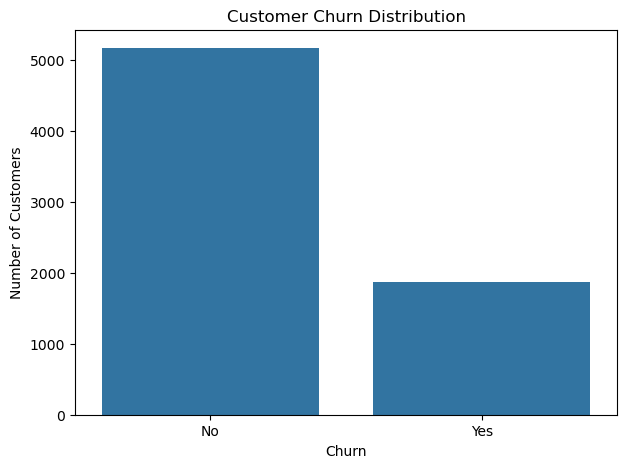

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [8]:
churn_percentage = (
    df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_percentage

churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

### Customer Demographics

In [13]:
# Gender
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [14]:
# Senior Citizens
df["senior_citizen"].value_counts()

senior_citizen
0    5890
1    1142
Name: count, dtype: int64

In [15]:
# Partner
df["partner"].value_counts()

partner
No     3639
Yes    3393
Name: count, dtype: int64

In [16]:
# Dependents
df["dependents"].value_counts()

dependents
No     4933
Yes    2099
Name: count, dtype: int64

## Churn by Demographics

In [17]:
## Gender vs Churn
pd.crosstab(
    df["gender"],
    df["churn"],
    normalize="index"
).mul(100).round(2)

churn,No,Yes
gender,,
Female,73.04,26.96
Male,73.80,26.20


In [18]:
## Senior Citizen vs Churn
pd.crosstab(
    df["senior_citizen"],
    df["churn"],
    normalize="index"
).mul(100).round(2)

churn,No,Yes
senior_citizen,,
0,76.35,23.65
1,58.32,41.68


In [20]:
## Partner vs Churn
pd.crosstab(
    df["partner"],
    df["churn"],
    normalize="index"
).mul(100).round(2)

churn,No,Yes
partner,,
No,67.02,32.98
Yes,80.28,19.72


In [21]:
# Dependents vs Churn
pd.crosstab(
    df["dependents"],
    df["churn"],
    normalize="index"
).mul(100).round(2)

churn,No,Yes
dependents,,
No,68.72,31.28
Yes,84.47,15.53


### Contract Analysis

In [22]:
contract_churn = pd.crosstab(
    df["contract"],
    df["churn"],
    normalize="index"
).mul(100).round(2)

contract_churn

churn,No,Yes
contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


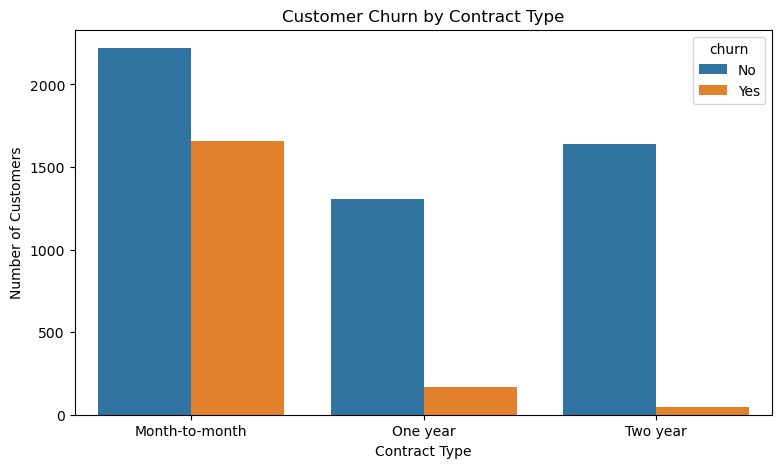

In [23]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="contract",
    hue="churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

## Payment Method Analysis

In [24]:
payment_churn = pd.crosstab(
    df["payment_method"],
    df["churn"],
    normalize="index"
).mul(100).round(2)

payment_churn

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


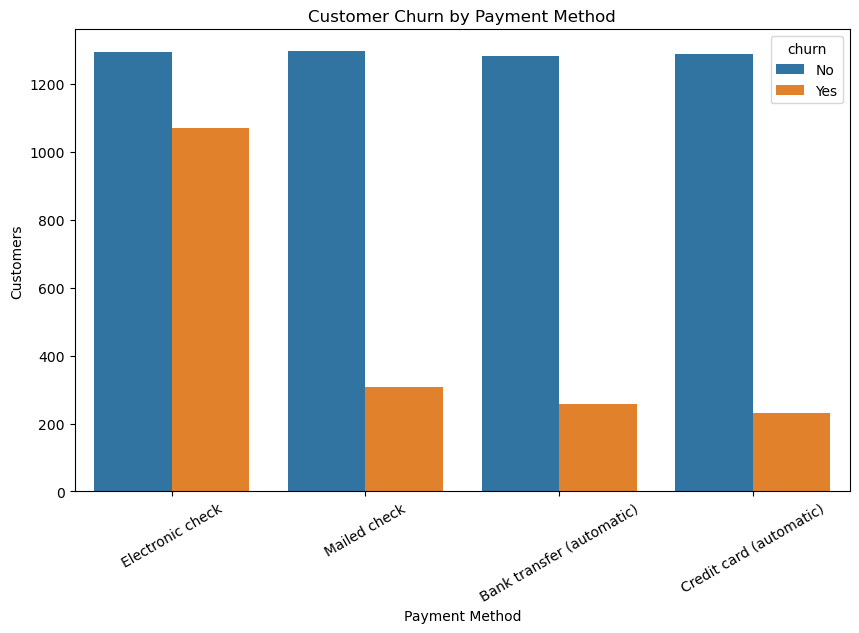

In [25]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="payment_method",
    hue="churn"
)

plt.xticks(rotation=30)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customers")

plt.show()

## Internet Service Analysis

In [26]:
internet_churn = pd.crosstab(
    df["internet_service"],
    df["churn"],
    normalize="index"
).mul(100).round(2)

internet_churn

churn,No,Yes
internet_service,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


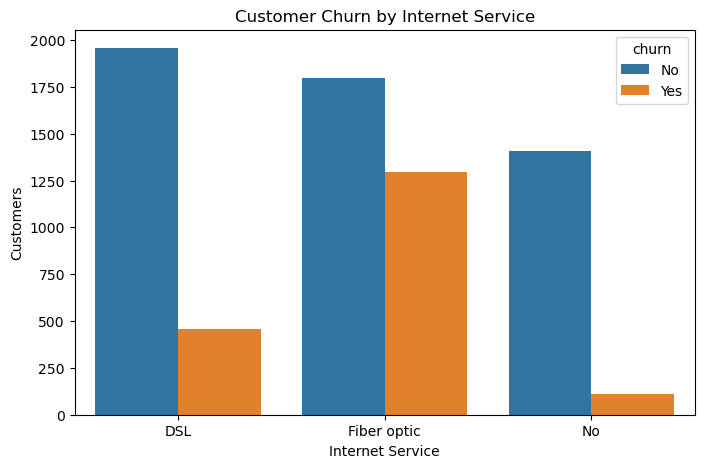

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="internet_service",
    hue="churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Customers")

plt.show()

## Tenure Analysis

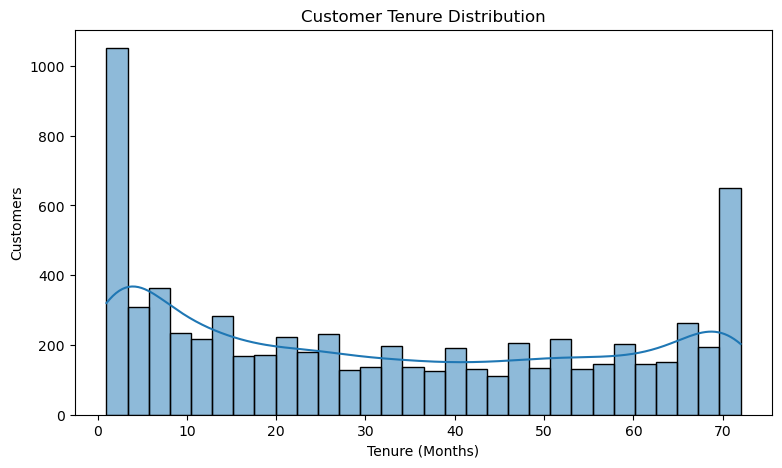

In [28]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customers")

plt.show()

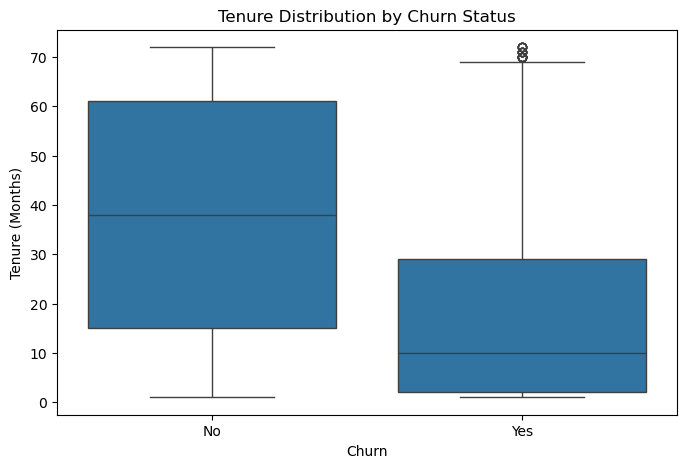

In [29]:
# Then compare tenure with churn:

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

## Monthly Charges Analysis

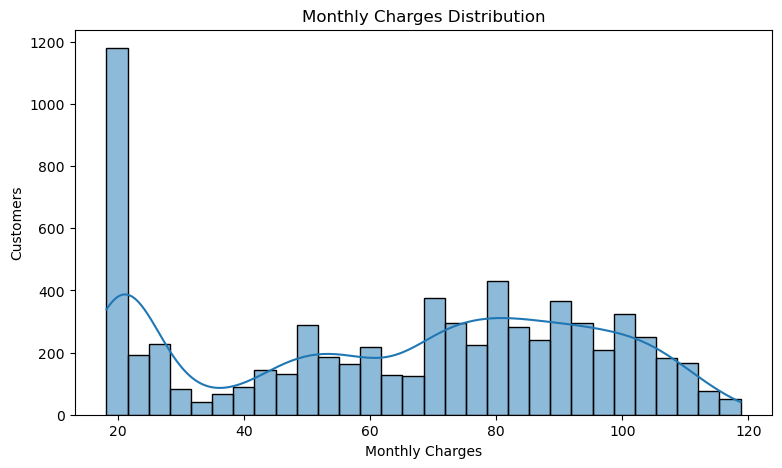

In [30]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="monthly_charges",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Customers")

plt.show()

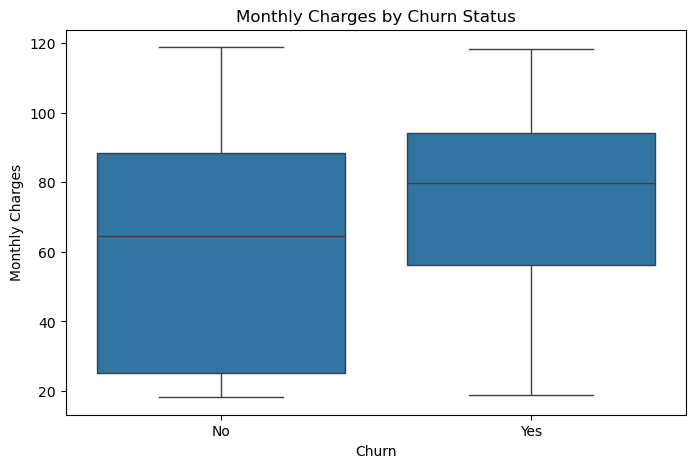

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="monthly_charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## Total Charges

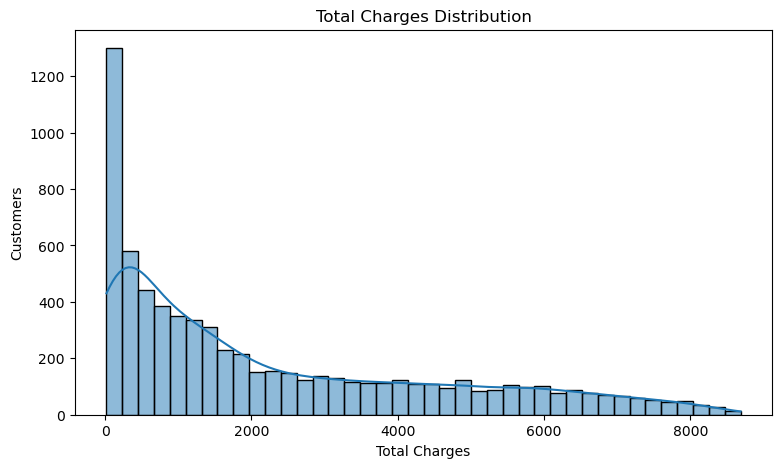

In [32]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="total_charges",
    bins=40,
    kde=True
)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Customers")

plt.show()

## Service Analysis

In [33]:
pd.crosstab(
    df["tech_support"],
    df["churn"],
    normalize="index"
).mul(100).round(2)

churn,No,Yes
tech_support,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


## Correlation Analysis

In [34]:
numeric_columns = [
    "senior_citizen",
    "tenure",
    "monthly_charges",
    "total_charges"
]

df[numeric_columns].corr()

,senior_citizen,tenure,monthly_charges,total_charges
senior_citizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
monthly_charges,0.219874,0.246862,1.000000,0.651065
total_charges,0.102411,0.825880,0.651065,1.000000


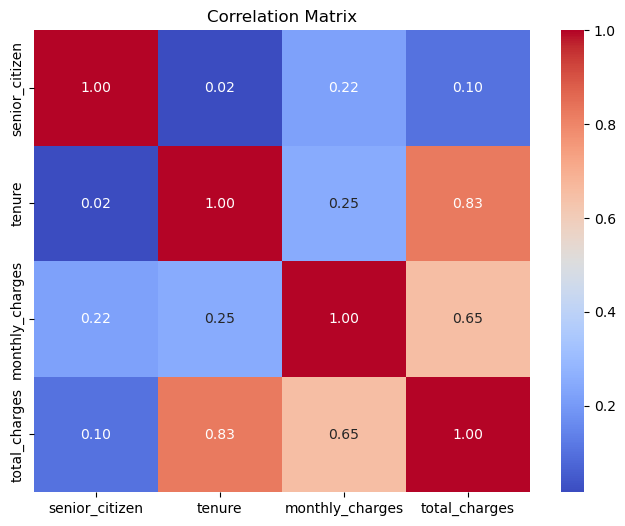

In [35]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# 🎯 Business Insights & Findings

The exploratory data analysis revealed several important patterns associated with customer churn.

## 1. Contract Type is a Major Churn Driver

### Finding
Month-to-month customers show significantly higher churn compared with customers on one-year and two-year contracts.

### Business Interpretation
Customers without long-term commitments have greater flexibility to switch providers.

### Recommendation
The company should encourage month-to-month customers to move toward longer-term contracts through:
- Contract upgrade discounts
- Loyalty benefits
- Reduced pricing for annual plans
- Personalized retention offers

---

## 2. Higher Monthly Charges are Associated with Higher Churn

### Finding
Customers who churn generally show higher monthly charges compared with retained customers.

### Business Interpretation
Customers paying higher monthly amounts may be more price-sensitive or may expect greater value from their services.

### Recommendation
The company should review pricing for high-charge customers and provide:
- Personalized discounts
- Bundled service plans
- Loyalty pricing
- Targeted retention offers

---

## 3. Customer Tenure is Strongly Associated with Churn

### Finding
Customers with shorter tenure tend to have a higher probability of churn, while long-tenure customers are generally more likely to remain with the company.

### Business Interpretation
New customers may not yet have developed strong loyalty toward the company.

### Recommendation
The company should introduce an early-stage customer retention program during the first few months, including:
- Onboarding support
- Welcome offers
- Service assistance
- Early loyalty rewards

---

## 4. Internet Service Type Shows Different Churn Patterns

### Finding
Churn rates vary across internet service categories, with some service types showing substantially higher churn than others.

### Business Interpretation
Differences may be related to pricing, service quality, customer expectations, or perceived value.

### Recommendation
The company should investigate service quality and customer satisfaction for high-churn internet service segments and consider targeted offers or service improvements.

---

## 5. Payment Method is Associated with Customer Churn

### Finding
Customer churn varies across payment methods, with certain payment methods showing higher churn than others.

### Business Interpretation
Payment behavior may be associated with customer engagement, convenience, or billing friction.

### Recommendation
The company should encourage convenient automatic payment methods through:
- Small incentives
- Simplified payment setup
- Auto-pay benefits
- Payment reminders

---

## 6. Additional Services Can Influence Retention

### Finding
Customers subscribed to services such as technical support and online security show different churn patterns compared with customers without these services.

### Business Interpretation
Additional services may increase customer engagement and perceived value.

### Recommendation
The company should consider bundling valuable services with core plans and offering targeted service upgrades to high-risk customers.

---

# 💡 Overall Business Conclusion

The analysis indicates that customer churn is influenced by a combination of:

- Contract commitment
- Customer tenure
- Monthly charges
- Internet service
- Payment method
- Additional subscribed services

The highest priority should be given to **short-tenure, month-to-month customers with higher monthly charges**, as this segment represents a potentially important retention opportunity.

The company should use customer segmentation and targeted retention campaigns rather than applying the same strategy to every customer.

These findings will be carried forward into the SQL business analysis and Power BI dashboard to quantify the business impact and support management decision-making.